# NOTEBOOK 06 — Risk Analysis

---

## Objective

The previous notebooks demonstrated that the sector-neutral momentum
signal has genuine predictive power (IC analysis) but generates weak
portfolio returns in certain market regimes (backtesting). This notebook
investigates **why** by decomposing the portfolio's risk and return
into systematic and idiosyncratic components.

The central question is:

> *Are the strategy's returns genuine alpha — compensation for bearing
> a unique, diversifiable risk — or are they simply a disguised form
> of systematic market risk (beta)?*

---

## The CAPM Framework

We use the **Capital Asset Pricing Model (CAPM)** as our primary
risk decomposition tool. CAPM states that the expected return of
any portfolio is:

$$r_p = r_f + \beta \cdot (r_m - r_f) + \alpha$$

Where:
- $r_p$ = portfolio return
- $r_f$ = risk-free rate (we use 0% as the portfolio is self-financing)
- $r_m$ = market return (S&P 500)
- $\beta$ = systematic risk exposure (sensitivity to market moves)
- $\alpha$ = excess return not explained by market exposure (**Jensen's Alpha**)

For a **dollar-neutral long/short portfolio**, we expect $\beta \approx 0$
by construction — the long and short legs should offset each other's
market exposure. If we find significant beta, it means the portfolio
has unintended market exposure that partially explains its returns.

---

## Beyond CAPM: Fama-French Three-Factor Model

CAPM is a single-factor model. Modern asset pricing uses
**multi-factor models** that decompose returns into exposures to
multiple systematic risk factors:

$$r_p = \alpha + \beta_m \cdot MKT + \beta_{smb} \cdot SMB +
\beta_{hml} \cdot HML + \epsilon$$

Where:
- **MKT** = Market excess return
- **SMB** = Small Minus Big (size factor: small caps vs large caps)
- **HML** = High Minus Low (value factor: high book-to-market vs low)

These factors were documented by **Fama & French (1993)** and represent
systematic risk premia that any investor can earn passively. If our
strategy's returns are explained by loadings on these factors, they
do not represent genuine alpha — they represent compensation for
bearing known, systematic risks.

---

## What We Analyze

1. **CAPM regression** — estimate alpha and beta for IS and OOS periods
2. **Fama-French regression** — decompose returns into MKT, SMB, HML
3. **Rolling beta** — does market exposure change over time?
4. **Factor exposure summary** — which systematic risks does the
   strategy inadvertently take?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Load portfolio returns
port_is  = pd.read_parquet('../data/portfolio_returns_sn.parquet')['gross']
port_oos = pd.read_parquet('../data/portfolio_returns_oos.parquet')['gross']
port_all = pd.concat([port_is, port_oos]).dropna()

# Load prices for market return calculation
prices = pd.read_parquet('../data/sp500_prices.parquet').ffill(limit=5)

print("=== DATA LOADED ===")
print(f"IS portfolio:  {len(port_is.dropna())} months")
print(f"OOS portfolio: {len(port_oos.dropna())} months")
print(f"Full period:   {len(port_all)} months")

=== DATA LOADED ===
IS portfolio:  95 months
OOS portfolio: 71 months
Full period:   166 months


## Step 1 — Compute Market Returns

We use the **equal-weighted average return of all S&P 500 stocks**
as our market proxy. This is more appropriate than a price-weighted
index for our analysis because our portfolio uses equal weighting.

The market excess return (MKT) is simply the market return minus
the risk-free rate. Since our portfolio is self-financing (dollar-neutral),
we assume a risk-free rate of 0%.

In [6]:
# Compute equal-weighted market return
monthly_prices  = prices.resample('M').last()
monthly_returns = monthly_prices.pct_change()
market_return   = monthly_returns.mean(axis=1)

# Align with portfolio periods
IS_END    = '2018-12-31'
OOS_START = '2019-01-01'

market_is  = market_return.loc[:IS_END]
market_oos = market_return.loc[OOS_START:]
market_all = market_return

print("=== MARKET RETURNS ===")
print(f"\nIn-sample market return:")
print(f"  Mean monthly: {market_is.mean()*100:.3f}%")
print(f"  Annualized:   {market_is.mean()*12*100:.2f}%")
print(f"\nOut-of-sample market return:")
print(f"  Mean monthly: {market_oos.mean()*100:.3f}%")
print(f"  Annualized:   {market_oos.mean()*12*100:.2f}%")

=== MARKET RETURNS ===

In-sample market return:
  Mean monthly: 1.427%
  Annualized:   17.12%

Out-of-sample market return:
  Mean monthly: 1.533%
  Annualized:   18.39%


## Step 2 — CAPM Regression

We regress the portfolio's monthly returns on the market return:

$$r_p(t) = \alpha + \beta \cdot r_m(t) + \epsilon(t)$$

For a dollar-neutral long/short portfolio we expect:
- **$\beta \approx 0$**: market neutrality by construction
- **$\alpha > 0$**: positive intercept indicating genuine excess return

We run this regression separately for the in-sample and out-of-sample
periods to detect any change in market exposure across regimes.

In [8]:
def run_capm(portfolio, market, label):
    """
    Run CAPM regression: r_p = alpha + beta * r_m + epsilon

    Parameters
    ----------
    portfolio : pd.Series, monthly portfolio returns
    market    : pd.Series, monthly market returns
    label     : str, label for display

    Returns
    -------
    results : dict with alpha, beta, r_squared, t_stats, p_values
    """
    # Align series
    df = pd.DataFrame({
        'portfolio': portfolio,
        'market'   : market
    }).dropna()

    X = sm.add_constant(df['market'])
    y = df['portfolio']

    model   = sm.OLS(y, X).fit()

    alpha   = model.params['const']
    beta    = model.params['market']
    r2      = model.rsquared
    t_alpha = model.tvalues['const']
    t_beta  = model.tvalues['market']
    p_alpha = model.pvalues['const']
    p_beta  = model.pvalues['market']

    print(f"\n  {label}")
    print(f"    Observations:  {len(df)}")
    print(f"    Alpha:         {alpha*100:+.4f}%/month  "
          f"({alpha*12*100:+.2f}%/year)  "
          f"[t={t_alpha:.2f}, p={p_alpha:.3f}]")
    print(f"    Beta:          {beta:+.4f}  "
          f"[t={t_beta:.2f}, p={p_beta:.3f}]")
    print(f"    R-squared:     {r2:.4f}")
    print(f"    Alpha sig.:    "
          f"{'YES (p<0.05)' if p_alpha < 0.05 else 'NO'}")
    print(f"    Beta sig.:     "
          f"{'YES (p<0.05)' if p_beta < 0.05 else 'NO'}")

    return {
        'alpha': alpha, 'beta': beta, 'r2': r2,
        't_alpha': t_alpha, 't_beta': t_beta,
        'p_alpha': p_alpha, 'p_beta': p_beta,
        'n': len(df)
    }

print("=" * 60)
print("   CAPM REGRESSION RESULTS")
print("=" * 60)

capm_is  = run_capm(port_is,  market_is,  'In-Sample  (2011-2018)')
capm_oos = run_capm(port_oos, market_oos, 'Out-of-Sample (2019-2024)')
capm_all = run_capm(port_all, market_all, 'Full Period (2011-2024)')
print("=" * 60)

   CAPM REGRESSION RESULTS

  In-Sample  (2011-2018)
    Observations:  95
    Alpha:         +0.4179%/month  (+5.01%/year)  [t=1.58, p=0.119]
    Beta:          -0.1831  [t=-2.55, p=0.012]
    R-squared:     0.0653
    Alpha sig.:    NO
    Beta sig.:     YES (p<0.05)

  Out-of-Sample (2019-2024)
    Observations:  71
    Alpha:         +0.1668%/month  (+2.00%/year)  [t=0.40, p=0.687]
    Beta:          -0.3086  [t=-4.17, p=0.000]
    R-squared:     0.2015
    Alpha sig.:    NO
    Beta sig.:     YES (p<0.05)

  Full Period (2011-2024)
    Observations:  166
    Alpha:         +0.3439%/month  (+4.13%/year)  [t=1.48, p=0.141]
    Beta:          -0.2647  [t=-5.24, p=0.000]
    R-squared:     0.1432
    Alpha sig.:    NO
    Beta sig.:     YES (p<0.05)


## Step 3 — Fama-French Three-Factor Model

We download the **Fama-French Three-Factor** data directly from
Kenneth French's data library. These are the standard academic
factors used in virtually all empirical asset pricing research.

The regression is:

$$r_p(t) = \alpha + \beta_m \cdot MKT_t + \beta_s \cdot SMB_t +
\beta_h \cdot HML_t + \epsilon(t)$$

If our momentum strategy has significant loadings on SMB or HML,
it means the strategy is inadvertently taking on size or value risk —
risks that investors can access cheaply via passive factor ETFs.
Only the intercept $\alpha$ represents genuine skill.

In [10]:
import pandas as pd
import io
import urllib.request

ff_url = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/"
    "ftp/F-F_Research_Data_Factors_CSV.zip"
)

try:
    import zipfile

    # Download zip
    req = urllib.request.Request(
        ff_url,
        headers={'User-Agent': 'Mozilla/5.0'}
    )
    with urllib.request.urlopen(req) as response:
        zip_data = response.read()

    # List files in zip
    with zipfile.ZipFile(io.BytesIO(zip_data)) as z:
        print(f"Files in zip: {z.namelist()}")
        csv_name = z.namelist()[0]
        with z.open(csv_name) as f:
            raw_text = f.read().decode('utf-8', errors='ignore')

    # Parse only monthly rows (YYYYMM format = 6 digits)
    lines = raw_text.split('\n')
    monthly_lines = ['Date,MKT,SMB,HML,RF']

    for line in lines:
        line = line.strip()
        if not line:
            continue
        first_token = line.split(',')[0].strip()
        if first_token.isdigit() and len(first_token) == 6:
            monthly_lines.append(line)

    print(f"Monthly rows found: {len(monthly_lines) - 1}")

    # Build DataFrame
    ff_monthly = pd.read_csv(io.StringIO('\n'.join(monthly_lines)))
    ff_monthly['Date'] = pd.to_datetime(
        ff_monthly['Date'].astype(str), format='%Y%m'
    ) + pd.offsets.MonthEnd(0)
    ff_monthly = ff_monthly.set_index('Date')
    ff_monthly = ff_monthly.apply(pd.to_numeric, errors='coerce') / 100

    # Rename market factor
    if 'Mkt-RF' in ff_monthly.columns:
        ff_monthly = ff_monthly.rename(columns={'Mkt-RF': 'MKT'})

    print("=== FAMA-FRENCH FACTORS LOADED ===")
    print(f"Available from: {ff_monthly.index[0].date()}")
    print(f"Available to:   {ff_monthly.index[-1].date()}")
    print(f"Observations:   {len(ff_monthly)}")
    print(f"\nFactor summary (monthly):")
    print(ff_monthly[['MKT', 'SMB', 'HML']].describe().round(4))

except Exception as e:
    print(f"Download failed: {e}")
    import traceback
    traceback.print_exc()
    ff_monthly = None

Files in zip: ['F-F_Research_Data_Factors.csv']
Monthly rows found: 1196
=== FAMA-FRENCH FACTORS LOADED ===
Available from: 1926-07-31
Available to:   2026-02-28
Observations:   1196

Factor summary (monthly):
             MKT        SMB        HML
count  1196.0000  1196.0000  1196.0000
mean      0.0069     0.0017     0.0035
std       0.0530     0.0315     0.0355
min      -0.2874    -0.1741    -0.1383
25%      -0.0199    -0.0162    -0.0142
50%       0.0108     0.0006     0.0014
75%       0.0365     0.0173     0.0176
max       0.3881     0.3596     0.3552


In [12]:
def run_ff3(portfolio, ff_factors, label):
    """
    Run Fama-French 3-factor regression.
    """
    df = pd.DataFrame({'portfolio': portfolio}).join(
        ff_factors[['MKT', 'SMB', 'HML']]
    ).dropna()

    X = sm.add_constant(df[['MKT', 'SMB', 'HML']])
    y = df['portfolio']

    model = sm.OLS(y, X).fit()

    print(f"\n  {label}")
    print(f"    Observations: {len(df)}")
    print(f"    R-squared:    {model.rsquared:.4f}")
    print()

    for factor in ['const', 'MKT', 'SMB', 'HML']:
        name  = 'Alpha' if factor == 'const' else factor
        coef  = model.params[factor]
        tval  = model.tvalues[factor]
        pval  = model.pvalues[factor]
        sig   = '***' if pval < 0.01 else ('**' if pval < 0.05
                else ('*' if pval < 0.10 else ''))
        if factor == 'const':
            print(f"    {name:8}: {coef*100:+.4f}%/month  "
                  f"({coef*12*100:+.2f}%/year)  "
                  f"[t={tval:.2f}] {sig}")
        else:
            print(f"    {name:8}: {coef:+.4f}  "
                  f"[t={tval:.2f}] {sig}")

    return model

if ff_monthly is not None:
    print("=" * 60)
    print("   FAMA-FRENCH 3-FACTOR REGRESSION")
    print("=" * 60)

    ff_is  = ff_monthly.loc['2011':'2018']
    ff_oos = ff_monthly.loc['2019':]

    ff_model_is  = run_ff3(port_is,  ff_is,  'In-Sample  (2011-2018)')
    ff_model_oos = run_ff3(port_oos, ff_oos, 'Out-of-Sample (2019-2024)')
    ff_model_all = run_ff3(port_all, ff_monthly, 'Full Period (2011-2024)')
    print("=" * 60)
    print("\n* p<0.10  ** p<0.05  *** p<0.01")

   FAMA-FRENCH 3-FACTOR REGRESSION

  In-Sample  (2011-2018)
    Observations: 95
    R-squared:    0.2135

    Alpha   : +0.2849%/month  (+3.42%/year)  [t=1.18] 
    MKT     : -0.1759  [t=-2.46] **
    SMB     : +0.0553  [t=0.51] 
    HML     : -0.4602  [t=-4.17] ***

  Out-of-Sample (2019-2024)
    Observations: 71
    R-squared:    0.3679

    Alpha   : -0.1370%/month  (-1.64%/year)  [t=-0.37] 
    MKT     : -0.2042  [t=-2.77] ***
    SMB     : -0.2715  [t=-2.10] **
    HML     : -0.3425  [t=-4.21] ***

  Full Period (2011-2024)
    Observations: 166
    R-squared:    0.2876

    Alpha   : +0.1216%/month  (+1.46%/year)  [t=0.57] 
    MKT     : -0.1976  [t=-3.91] ***
    SMB     : -0.1249  [t=-1.49] 
    HML     : -0.3737  [t=-6.05] ***

* p<0.10  ** p<0.05  *** p<0.01


## Step 4 — Rolling Beta Analysis

A static beta estimate assumes the portfolio's market exposure is
constant over time. In practice, beta may vary significantly across
market regimes — a momentum portfolio may become more market-exposed
during certain periods (e.g. when all momentum stocks are in the
same sector).

We compute a **12-month rolling beta** to detect any time variation
in market exposure. A well-constructed market-neutral strategy should
show rolling beta consistently close to zero.

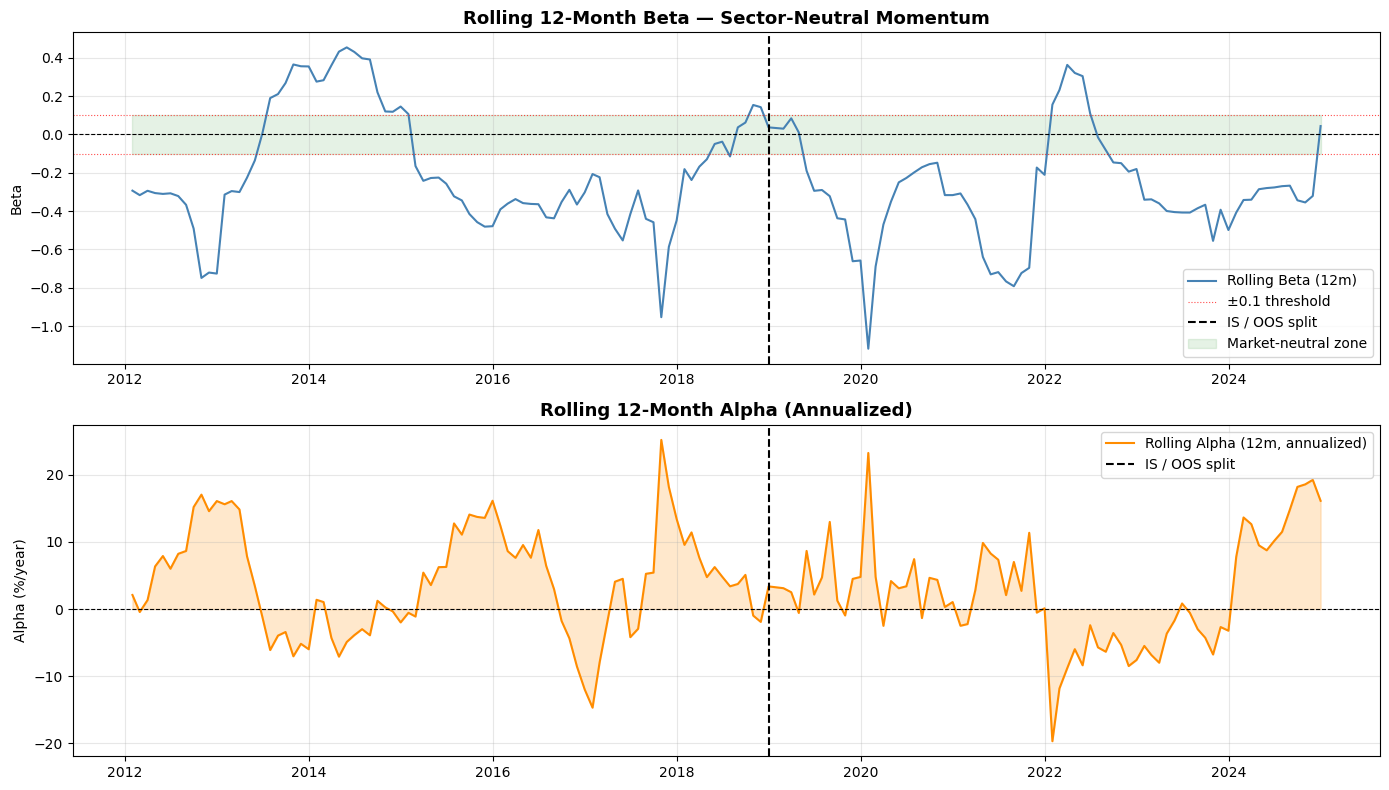

In [14]:
def compute_rolling_beta(portfolio, market, window=12):
    """
    Compute rolling OLS beta with a given window (months).
    """
    df = pd.DataFrame({
        'portfolio': portfolio,
        'market'   : market
    }).dropna()

    rolling_beta = []

    for i in range(window, len(df) + 1):
        chunk = df.iloc[i-window:i]
        X     = sm.add_constant(chunk['market'])
        y     = chunk['portfolio']
        model = sm.OLS(y, X).fit()
        rolling_beta.append({
            'date': df.index[i-1],
            'beta': model.params['market'],
            'alpha': model.params['const']
        })

    return pd.DataFrame(rolling_beta).set_index('date')

# Compute rolling beta for full period
rolling = compute_rolling_beta(port_all, market_all, window=12)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Rolling Beta
axes[0].plot(rolling.index, rolling['beta'],
             color='steelblue', linewidth=1.5, label='Rolling Beta (12m)')
axes[0].axhline(0,   color='black', linewidth=0.8, linestyle='--')
axes[0].axhline(0.1, color='red',   linewidth=0.8,
                linestyle=':', alpha=0.7, label='±0.1 threshold')
axes[0].axhline(-0.1, color='red',  linewidth=0.8,
                linestyle=':', alpha=0.7)
axes[0].axvline(pd.Timestamp('2019-01-01'),
                color='black', linewidth=1.5,
                linestyle='--', label='IS / OOS split')
axes[0].fill_between(rolling.index, -0.1, 0.1,
                     alpha=0.1, color='green',
                     label='Market-neutral zone')
axes[0].set_title('Rolling 12-Month Beta — Sector-Neutral Momentum',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Beta')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Rolling Alpha (annualized)
axes[1].plot(rolling.index, rolling['alpha'] * 12 * 100,
             color='darkorange', linewidth=1.5,
             label='Rolling Alpha (12m, annualized)')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axvline(pd.Timestamp('2019-01-01'),
                color='black', linewidth=1.5, linestyle='--',
                label='IS / OOS split')
axes[1].fill_between(rolling.index, 0,
                     rolling['alpha'] * 12 * 100,
                     alpha=0.2, color='darkorange')
axes[1].set_title('Rolling 12-Month Alpha (Annualized)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Alpha (%/year)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/rolling_beta_alpha.png',
            dpi=150, bbox_inches='tight')
plt.show()

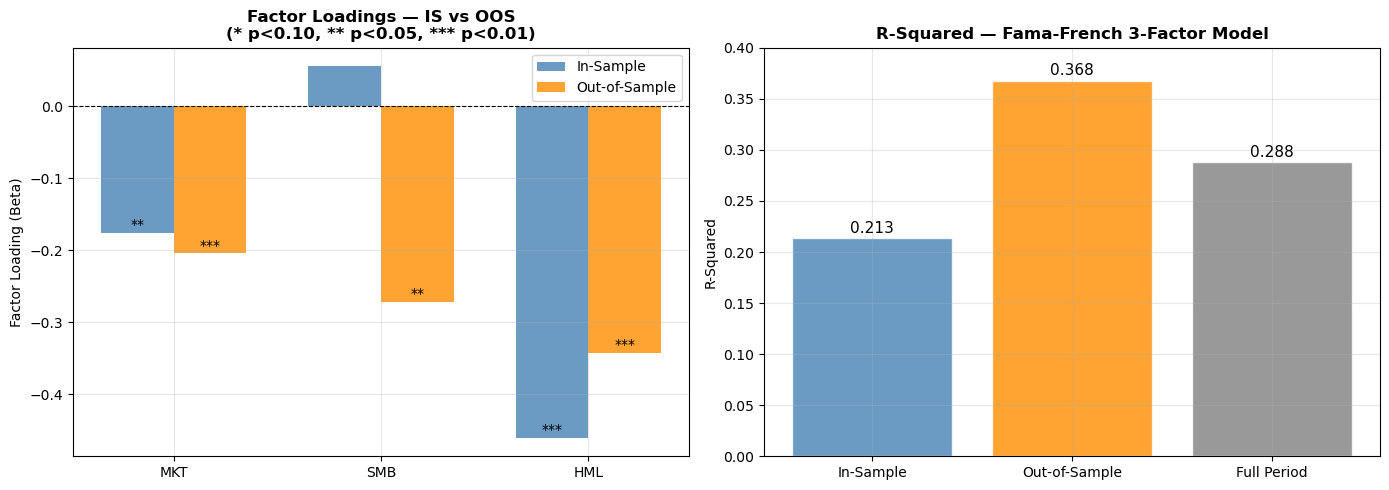

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if ff_monthly is not None:
    # Factor loadings IS vs OOS
    factors   = ['MKT', 'SMB', 'HML']
    coefs_is  = [ff_model_is.params[f]  for f in factors]
    coefs_oos = [ff_model_oos.params[f] for f in factors]
    pvals_is  = [ff_model_is.pvalues[f]  for f in factors]
    pvals_oos = [ff_model_oos.pvalues[f] for f in factors]

    x     = np.arange(len(factors))
    width = 0.35

    bars_is = axes[0].bar(
        x - width/2, coefs_is, width,
        label='In-Sample', color='steelblue', alpha=0.8
    )
    bars_oos = axes[0].bar(
        x + width/2, coefs_oos, width,
        label='Out-of-Sample', color='darkorange', alpha=0.8
    )

    # Add significance stars
    for i, (p_is, p_oos) in enumerate(zip(pvals_is, pvals_oos)):
        star_is  = '***' if p_is  < 0.01 else ('**' if p_is  < 0.05
                   else ('*' if p_is  < 0.10 else ''))
        star_oos = '***' if p_oos < 0.01 else ('**' if p_oos < 0.05
                   else ('*' if p_oos < 0.10 else ''))
        if star_is:
            axes[0].text(i - width/2, coefs_is[i] + 0.005,
                         star_is, ha='center', fontsize=10)
        if star_oos:
            axes[0].text(i + width/2, coefs_oos[i] + 0.005,
                         star_oos, ha='center', fontsize=10)

    axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(factors)
    axes[0].set_title('Factor Loadings — IS vs OOS\n'
                      '(* p<0.10, ** p<0.05, *** p<0.01)',
                      fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Factor Loading (Beta)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # R-squared comparison
    r2_values = [
        ff_model_is.rsquared,
        ff_model_oos.rsquared,
        ff_model_all.rsquared
    ]
    labels_r2 = ['In-Sample', 'Out-of-Sample', 'Full Period']
    colors_r2 = ['steelblue', 'darkorange', 'gray']

    axes[1].bar(labels_r2, r2_values,
                color=colors_r2, alpha=0.8, edgecolor='white')
    axes[1].set_title('R-Squared — Fama-French 3-Factor Model',
                      fontsize=12, fontweight='bold')
    axes[1].set_ylabel('R-Squared')
    axes[1].set_ylim(0, 0.4)
    axes[1].grid(alpha=0.3)

    for i, (label, val) in enumerate(zip(labels_r2, r2_values)):
        axes[1].text(i, val + 0.005, f'{val:.3f}',
                     ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../data/factor_exposures.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [18]:
rolling.to_parquet('../data/rolling_beta.parquet')

print("=== FILES SAVED ===")
print("  data/rolling_beta.parquet")
print("  data/rolling_beta_alpha.png")
print("  data/factor_exposures.png")
print("\nReady for Research Memo")

=== FILES SAVED ===
  data/rolling_beta.parquet
  data/rolling_beta_alpha.png
  data/factor_exposures.png

Ready for Research Memo
